<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 10: Integraci&oacute;n num&eacute;rica</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas F&uuml;hrer y Manuel A. Sánchez | <b>Fecha:</b> 26 de junio, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-izq: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-izq: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>Cuadraturas en dos y tres dimensiones</li>
        <li>Cuadraturas compuestas</li>
        <li>Cuadraturas adaptativas</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-izq: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> _______________________________________</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> _________________________</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 2.4.6
Estilo usado: <function context at 0x7fda5168d430>


<div class="alert-block alert-warning "; style=" border-izq: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría:</h3>
    Se discuta en cada secci&oacute;n.
</div>

# Cuadratura sobre $[-1,1]^d$ con $d\geq 2$

Sea $Q(f) = \sum_{j=0}^n A_j f(x_j)$ una cuadratura en una dimensi&oacute;n (para aproximar $I(f) = \int_{-1}^1 f(x)\,\mathrm{d}x$).
Podemos usar esta cuadratura para definir cuadratura en dimensiones arbitra. Por ejemplo para $d=2$, 
\begin{align*}
I_2(f):=\int_{-1}^1 \int_{-1}^1 f(x,y)\,\mathrm{d}x\mathrm{d}y \approx \int_{-1}^1 \sum_{j=0}^n A_j f(x_j,y) \,\mathrm{d}y = \sum_{j=0}^n A_j \int_{-1}^1 f(x_j,y)\,\mathrm{d}y \approx \sum_{j=0}^n \sum_{k=0}^n A_j A_kf(x_j,x_k) =: Q_2(f)
\end{align*}
y similarmente en tres dimensiones
\begin{align*}
I_3(f):=\int_{-1}^1 \int_{-1}^1 \int_{-1}^1 f(x,y,z)\,\mathrm{d}x\mathrm{d}y\mathrm{d}z \approx  \sum_{j=0}^n \sum_{k=0}^n \sum_{k=0}^n A_j A_k A_\ell f(x_j,x_k,x_\ell) =: Q_3(f)
\end{align*}

**Regla del trapezoide** (sobre [-1,1]) es $Q(f) = f(-1)+f(1)$

**Regla de Simpson** (sobre [-1,1]) es $Q(f) = \frac13(f(-1)+4f(0)+f(1))$

In [3]:
def integrar2D(f,nodos,pesos):
    Q = 0.0
    for j in range(len(nodos)):
        for k in range(len(nodos)):
            Q += pesos[j]*pesos[k]*f(nodos[j],nodos[k])
    return Q

In [4]:
# Regla del trapezoide en 2D
nodos = np.array([-1.0, 1.0])
pesos = np.array([1.0, 1.0])

# integramos la funcion de 2 variables
f = lambda x,y: x*y**3

# integral exacta es 0 (por simetria)
Q = integrar2D(f,nodos,pesos)
print('Valor exacto: ',0.0)
print('Cuadratura  : ',Q)

Valor exacto:  0.0
Cuadratura  :  0.0


In [5]:
f = lambda x,y: x**2*y**2
Q = integrar2D(f,nodos,pesos)
print('Valor exacto: ',4.0/9.0)
print('Cuadratura  : ',Q)

Valor exacto:  0.4444444444444444
Cuadratura  :  4.0


<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Escribe un programa que aproxima la integral de una funci&oacute;n en tres variables sobre el dominio $[-1,1]^3$. Use la regla de Simpson. 
</div>

In [6]:
# Tu codigo va aqui


<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Verifique num&eacute;ricamene el grado de exactitud de la regla de trapezoide y regla de Simpson en 2 dimensiones. 
    Para hacerlo considere los monomios $f(x,y) = x^ky^m$, $k,m=0,1,2,...$. 
</div>

In [7]:
# Tu codigo va aqui


# Cuadraturas compuestas

Consideramos nodos equidistantes $x_0,...,x_n$ de un intervalo $[a,b]$ y $h:= (b-a)/n$. 
La cuadratura compuesta (regla del trapezoide) es
\begin{align*}
Q_h(f) = \frac{h}2\Big(f(x_0) + 2\sum_{j=1}^{n-1}f(x_j) + f(x_n)\Big)
\end{align*}
Con $I(f) = \int_a^b f(x)\,\mathrm{d}x$ tenemos que
\begin{align*}
|I(f)-Q_h(f)| = \mathcal{O}(n^{-2}) \quad\text{para } n\to\infty,
\end{align*}
si $f\in C^2([a,b])$.

In [46]:
def trapezoideCompuesta(f,a,b,n):
    h = (b-a)/n
    Q = f(a)+f(b) # f(x_0) + f(x_n)
    for j in range(1,n):
        Q += 2.0*f(a+j*h)
    Q = Q*h/2.0
    return Q   

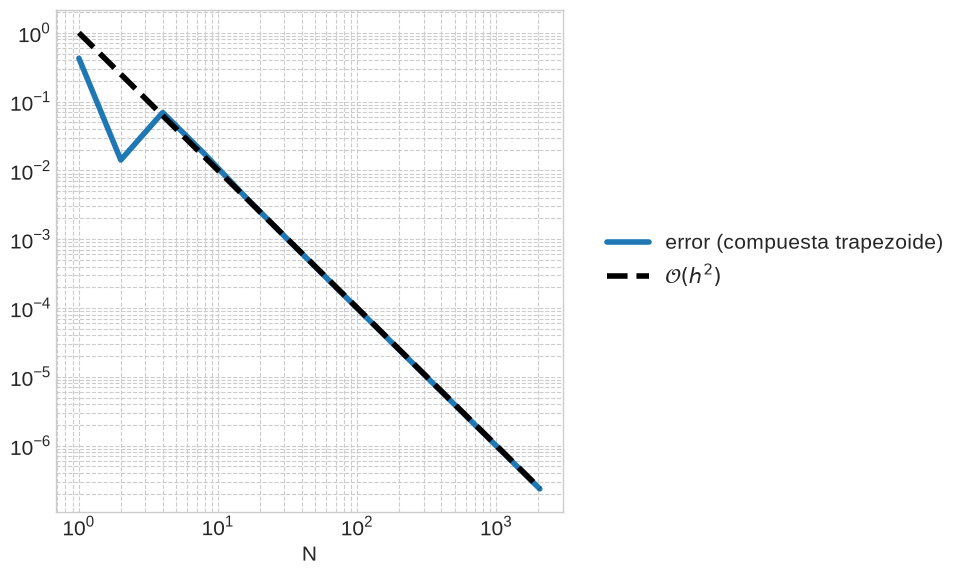

In [93]:
f = lambda x: np.sin(20*x)
a = 0
b = 1
# Valor exacto de la integral I(f)
If = 2.959589690933040e-02

N = [2**j for j in range(12)]
err = np.zeros(len(N))

for j in range(len(N)):
    err[j] = abs(If-np.abs(trapezoideCompuesta(f,a,b,N[j])))
    
# Graficar
plt.figure(figsize=(10, 6))
plt.loglog(N, err, label='error (compuesta trapezoide)', linewidth=4)
plt.loglog(N, [(b-a)/N[j]**2 for j in range(len(N))], '--k', label='$\\mathcal{O}(h^2)$', linewidth=4)

# formato
plt.rc('font', size=15)
plt.xlabel('N')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

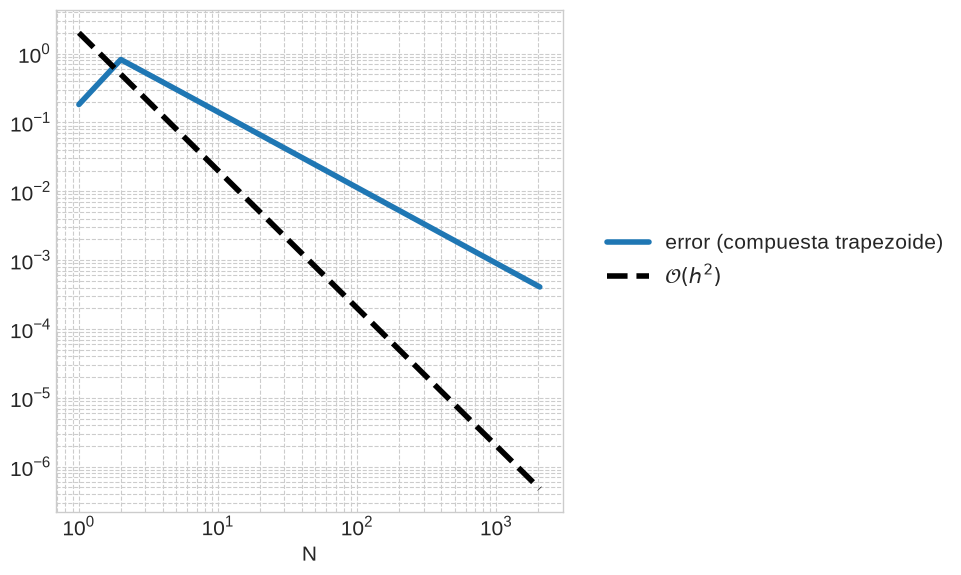

In [115]:
f = lambda x: np.abs(x)**(1/10)
a = -1
b = 1
# Valor exacto de la integral I(f)
If = 20.0/11.0

N = [2**j for j in range(12)]
err = np.zeros(len(N))

for j in range(len(N)):
    err[j] = np.abs(If-trapezoideCompuesta(f,a,b,N[j]))
    
# Graficar
plt.figure(figsize=(10, 6))
plt.loglog(N, err, label='error (compuesta trapezoide)', linewidth=4)
plt.loglog(N, [(b-a)/N[j]**2 for j in range(len(N))], '--k', label='$\\mathcal{O}(h^2)$', linewidth=4)

# formato
plt.rc('font', size=15)
plt.xlabel('N')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    En el &uacute;ltimo ejemplo se nota que la convergencia es mas lenta (la funci&oacute;n $f$ no es suficientemente regular). Determine num&eacute;ricamente el orden de convergencia. 
</div>

In [7]:
# Tu codigo va aqui


<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Implemente la regla compuesta de Simpson:
    \begin{align*}
    Q(f) = \frac{h}3\Big( f(x_0) + 2\sum_{j=1}^{n-1} f(x_j) + 4\sum_{j=0}^{n-1} f\big(\frac{x_j+x_{j+1}}2\big) + f(x_n)\Big), \quad h = \frac{b-a}{2n}.
    \end{align*}
    Verifique num&eacute;ricamente $|I(f)-Q(f)| = \mathcal{O}(h^4)$, para $[a,b]=[0,1]$ y $f(x) = \sin(20x)$.
</div>

In [7]:
# Tu codigo va aqui


# Cuadraturas adaptativas
El &uacute;ltimo ejemplo (regla compuesta trapezoide con funci&oacute;n $f(x) = |x|^{1/10}$ sobre $[-1,1]$) motiva usar estrategicas *adaptativas* para mejorar la aproximaci&oacute;n. 

La idea es la siguiente: Sobre cada intervalo $[x_{j-1},x_j]$ queremos *estimar* el error. Si el error es (relativamente) grande, dividimos el intervalo en 2 intervalos. Eso genera una nueva particici&oacute;n del intervalo $[a,b]$ que en general no va a ser uniforme. 

Una posibilidad simple de calcular el error sobre $[x_{j-1}.x_j]$ es: Calculamos la cuadratura sobre $[x_{j-1},x_j]$ como siempre. Digamos eso nos da el valor $Q_j$. Despues calculamos la cuadratura sobre los intervalos $[x_{j-1},m]$ y $[m,x_j]$, donde $m = (x_{j-1}+x_j)/2$, digamos los 2 valores $\widehat Q_{j,1}$, $\widehat Q_{j,2}$. 
Podemos estimar el error comparando estos valores, es decir, si $|\widehat Q_{j,1}+\widehat Q_{j,2}-Q_j|>\tau$ donde $\tau\in(0,1)$ es una tolerancia dada.

Es posible escribir un programa recursivo

In [75]:
def trapezoideAdaptativaRecursiva(f,a,b,tol=1e-15):
    c = (a+b)/2.0 # punto medio
    fa = f(a)
    fb = f(b)
    fc = f(c)  
    
    # Calcular Q y Q_1, Q_2
    Q = (b-a)/2.0*(fa+fb)
    Q1 = (b-a)/4.0*(fa+fc)
    Q2 = (b-a)/4.0*(fc+fb)

    if(np.abs(Q1+Q2-Q)>tol):
        return trapezoideAdaptativaRecursiva(f,a,c,tol)+trapezoideAdaptativaRecursiva(f,c,b,tol)
    else:
        return Q1+Q2

In [74]:
f = lambda x: np.abs(x)**(1/10)
a = -1
b = 1
# Valor exacto de la integral I(f)
If = 20.0/11.0

Q = trapezoideAdaptativaRecursiva(f,a,b,1e-10)
print('Error: ',np.abs(If-Q))

Error:  3.852122776315525e-08


<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Implementa una versi&oacute;n adaptativa de la regla de Simpson.
</div>

In [7]:
# Tu codigo va aqui


Tal vez los programas recursivos no son muy demostrativo. Veremos una versi&oacute;n con lupos:

In [100]:
def trapezoideAdaptivaNoRecursiva(f, a, b, tol=1e-12):
    # comenzamos con una malla con un elemento (intervalo [a,b])
    fa, fb = f(a), f(b)
    malla = {a: fa, b: fb}

    # generamos lista, intervalos (a,b,tol)
    intervalos = [(a, b, tol)]
    Q = 0.0

    while intervalos:
        izq, der, tolActual = intervalos.pop()

        f_izq = malla[izq]
        f_der = malla[der]

        # punto medio
        mid = (izq + der) / 2.0
        if mid not in malla:
            malla[mid] = f(mid)
        f_mid = malla[mid]

        # cuadratura sobre intervalo
        I_coarse = (der - izq) * (f_izq + f_der) / 2.0

        # cuadratura sobre intervalo refinado
        I_izq = (mid - izq) * (f_izq + f_mid) / 2.0
        I_der = (der - mid) * (f_mid + f_der) / 2.0
        I_fine = I_izq + I_der

        # estimacion del error
        error = abs(I_fine - I_coarse)

        if error <= tolActual:
            # error dentro tolerancia --> OK
            Q += I_fine
        else:
            # Si no, dividir en dos intervalos
            intervalos.append((mid, der, tolActual / 2.0))
            intervalos.append((izq, mid, tolActual / 2.0))

    # Sortear la malla (es decir, los nodos)
    mallaSorteada = sorted(malla.items())

    return Q, mallaSorteada


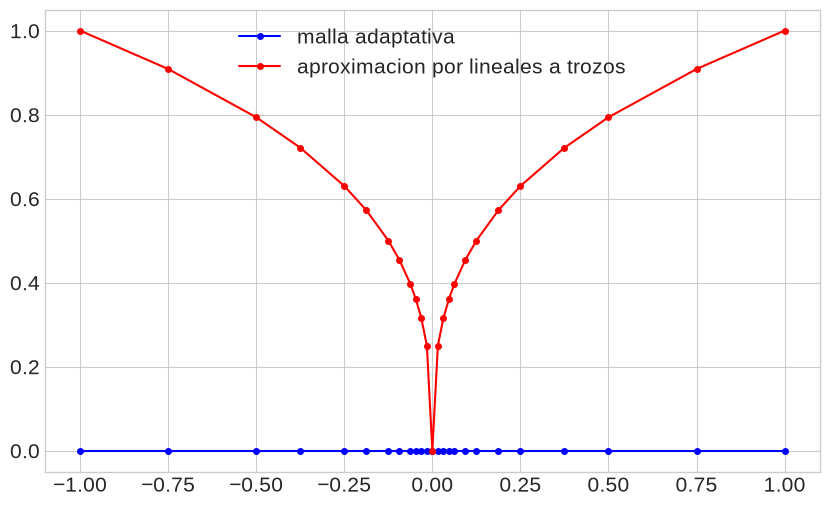

In [134]:
f = lambda x: np.abs(x)**(1/3)
If = 3.0/2.0
a = -1
b = 1

Q, malla = trapezoideAdaptivaNoRecursiva(f,a,b,1e-1)

# Extract coordinates for plotting
x = [nodo[0] for nodo in malla]
y = [nodo[1] for nodo in malla]

plt.figure(figsize=(10, 6))

# Plot the actual trapezoids / linear segments
plt.plot(x, np.zeros(len(x)), "b.-", markersize=8, label="malla adaptativa")
plt.plot(x, y, "r.-", markersize=8, label="aproximacion por lineales a trozos")
plt.legend()
plt.show()

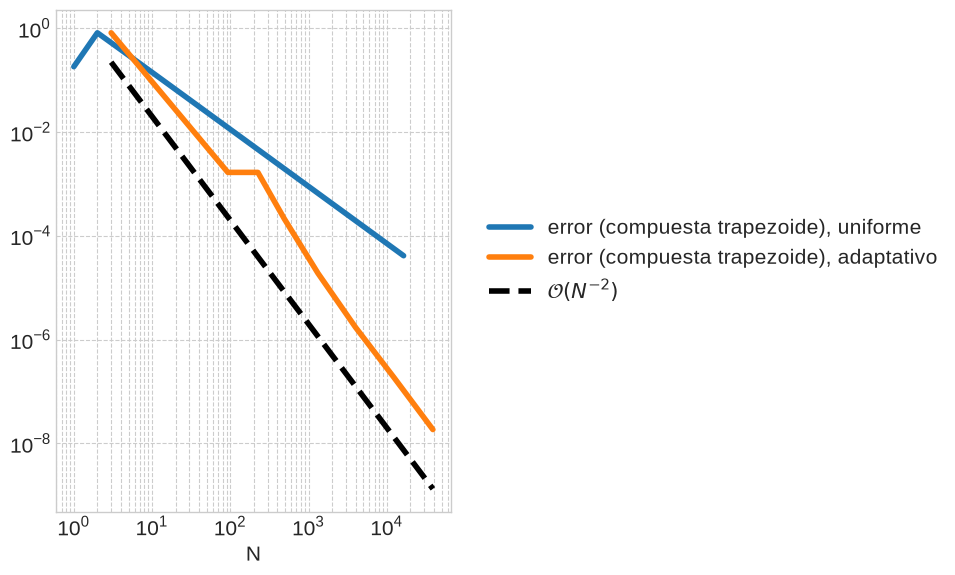

In [133]:
f = lambda x: np.abs(x)**(1/10)
If = 20.0/11.0
a = -1
b = 1

# Ejemplo con particion uniforme
N = [2**j for j in range(15)]
err = np.zeros(len(N))
for j in range(len(N)):
    err[j] = np.abs(If-trapezoideCompuesta(f,a,b,N[j]))

# Con mallas adaptativas
TOL = [10**(-j) for j in range(8)]
errAdap = np.zeros(len(TOL))
NAdap = np.zeros(len(TOL))
for j in range(len(TOL)):
    Q, malla = trapezoideAdaptivaNoRecursiva(f,a,b,TOL[j])

    errAdap[j] = abs(If-Q)
    NAdap[j] = len(malla)

# Graficar
plt.figure(figsize=(10, 6))
plt.loglog(N, err, label='error (compuesta trapezoide), uniforme', linewidth=4)
plt.loglog(NAdap,errAdap,label='error (compuesta trapezoide), adaptativo', linewidth=4)
plt.loglog(NAdap, [(b-a)/NAdap[j]**2 for j in range(len(NAdap))], '--k', label='$\\mathcal{O}(N^{-2})$', linewidth=4)

# formato
plt.rc('font', size=15)
plt.xlabel('N')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc='center left')
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()


Observaci&oacute;n: Recuperamos la convergencia optima en el sentido que el error se comparte como $\mathcal{O}(N^{-2})$ para $N\to \infty$ si usamos la estrategia adaptativa.

<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio (sin evaluaci&oacute;n):</h3>
    Haz un par de experimentos usando funciones discontinuas, comparando particiones uniformes con particiones adaptativas. 
    (por ejemplo, puede usar la funci&oacute;n de Heaviside)
</div>

In [7]:
# Tu codigo va aqui


---
<div class="alert alert-block alert-success"> 

## Evaluaci&oacute;n:

</div>

<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 1:</h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [9]:
# Espacio para tu codigo:


<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 2:</h3>
Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [10]:
# Espacio para tu codigo:



<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 3: </h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-izq: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [11]:
# Espacio para tu codigo:


